In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import pymysql
import matplotlib.pyplot as plt
from scipy.stats import shapiro, normaltest, ttest_ind, iqr, stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("Airbnb Listings Bangkok.csv")

### **Dictionary**

- id : Airbnb's unique identifier for the listing.
- name : Name of the listing.
- host_id : Airbnb's unique identifier for the host/user.
- host_name : Name of the host. Usually, just the first name(s).
- neighborhood: The neighborhood is geocoded using the latitude and longitude against neighborhoods as defined by open or public digital shapefiles.
- latitude : Uses the World Geodetic System (WGS84) projection for latitude.
- longitude : Uses the World Geodetic System (WGS84) projection for longitude.
- room_type : [Entire home/apt |Private room| Shared room| Hotel]
- minimum_nights : The minimum number of night stays for the listing (calendar rules may differ).
- number_of_reviews : The number of reviews the listing has.
- last_review : The date of the last/newest review. calculated_host_listings_count : The number of listings the host has in the current scrape in the city/region geography.
- availability_365 : Avaliability_x. The calendar determines the availability of the listing x days in the future. Note a listing may be available because it has been booked by a guest or blocked by the host.
- number_of_reviews_ltm : The number of reviews the listing has (in the last 12 months).

### **Background**
As a data analyst at a consulting firm partnering with Airbnb’s Bangkok operation, I am currently analyzing the city’s listing dataset to uncover insights that could improve platform performance and user satisfaction. The dataset includes details such as listing IDs, host information, location coordinates, room types, pricing, availability, reviews, and the number of listings per host. These insights will help the Marketing team refine marketing strategies, increase booking conversions, and identify opportunities to enhance listing quality and overall competitiveness.

#### **Hypotheses (Dataset Problems to Tackle)**
1. Some property listings are missing accommodation names, and the current system allows these incomplete entries.
2. There are listings with availability set to zero, indicating properties that are not actually bookable.
3. Duplicate listings exist within the dataset, which could result in data inconsistencies and poor user experience.
4. A significant drop in the number of reviews is observed in 2021.
5. Some properties have a disproportionately low number of reviews despite having a high volume of listings.

In [4]:
# DATA CLEANING
listItem = []

for col in df.columns:
    listItem.append([col, df[col].nunique(), df[col].unique()])

airbnb_desc= pd.DataFrame(listItem, columns=['Column Name', 'Number of Unique', 'Unique Sample'])
airbnb_desc

,Column Name,Number of Unique,Unique Sample
0,Unnamed: 0,15854,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,id,15854,"[27934, 27979, 28745, 35780, 941865, 1704776, ..."
2,name,14794,"[Nice room with superb city view, Easy going l..."
3,host_id,6659,"[120437, 120541, 123784, 153730, 610315, 21296..."
4,host_name,5312,"[Nuttee, Emy, Familyroom, Sirilak, Kasem, Wimo..."
5,neighbourhood,50,"[Ratchathewi, Bang Na, Bang Kapi, Din Daeng, B..."
6,latitude,9606,"[13.75983, 13.66818, 13.75232, 13.78823, 13.76..."
7,longitude,10224,"[100.54134, 100.61674, 100.62402, 100.57256, 1..."
8,room_type,4,"[Entire home/apt, Private room, Hotel room, Sh..."
9,price,3040,"[1905, 1316, 800, 1286, 1000, 1558, 1461, 700,..."


**RESULT**

Based on the dataset, in total, the dataset contains 17 columns, with unique values ranging from as few as 4 (room_type) to as many as 15,854 (id and Unnamed: 0), indicating a mix of categorical and unique columns.

In [5]:
df.columns.tolist()

['Unnamed: 0',
 'id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'number_of_reviews_ltm']

In [6]:
# Standardizing Column Names

df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

**Epxlanation:**
- Standardizing the columns figure in order to simplify the data processing.


In [7]:
# Breakdown the Dataset

display("--- Data Types ---")
display(df.dtypes)

display("--- Missing Values (Top 10) ---")
display(df.isna().sum().sort_values(ascending=False).head(10))

display("Duplicate rows:")
display(df.duplicated().sum())


'--- Data Types ---'

unnamed:_0                          int64
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
dtype: object

'--- Missing Values (Top 10) ---'

reviews_per_month    5790
last_review          5790
name                    8
host_name               1
unnamed:_0              0
neighbourhood           0
latitude                0
id                      0
host_id                 0
room_type               0
dtype: int64

'Duplicate rows:'

np.int64(0)

**Datasets Information**

- Data Types (df.dtypes) – shows the type of each column (e.g., integer, float, object).
- Missing Values (df.isna().sum()) – counts how many missing values are in each column, and shows the top 10 columns with the most missing data which (reviews_per_month), (last_review), (name), and (host_name) still need to be extracted. 
- Duplicate Rows (df.duplicated().sum()) – counts how many exact duplicate rows exist in the data.

In [8]:
df.describe().round(0)

,unnamed:_0,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,15854.0,1.585400e+04,15854.0,15854.0,15854.0,15854.0,15854.0,15854.0,10064.0,15854.0,15854.0,15854.0
mean,7926.0,1.579397e+17,154105784.0,14.0,101.0,3218.0,15.0,17.0,1.0,14.0,244.0,3.0
std,4577.0,2.946015e+17,131872648.0,0.0,0.0,24972.0,51.0,41.0,1.0,30.0,126.0,9.0
min,0.0,2.793400e+04,58920.0,14.0,100.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
25%,3963.0,2.104509e+07,39744308.0,14.0,101.0,900.0,1.0,0.0,0.0,1.0,138.0,0.0
50%,7926.0,3.503734e+07,122455569.0,14.0,101.0,1429.0,1.0,2.0,0.0,4.0,309.0,0.0
75%,11890.0,5.256154e+07,239054688.0,14.0,101.0,2429.0,7.0,13.0,1.0,13.0,360.0,3.0
max,15853.0,7.908162e+17,492665929.0,14.0,101.0,1100000.0,1125.0,1224.0,19.0,228.0,365.0,325.0


## **Variable Insights**
**1. id and host_id**

- Unique identifiers; statistical values (mean, std) are not analytically meaningful.

- No missing values, indicating consistent dataset structure.

**2. latitude and longitude**

- Constant values around 14 (latitude) and 101 (longitude), confirming all listings are located in Bangkok.

- Standard deviation is zero, meaning no geolocation anomalies.

**3. price**

- Mean price: 3,219 THB per night

- Median price: 1,428 THB (indicates right-skewed distribution)

- Maximum price: 1,100,000 THB (clear outlier)

**4. minimum_nights**

- Median = 1 night (most hosts allow short stays)

- Maximum = 1125 nights (outlier, likely long-term rental or incorrect data)

**5. number_of_reviews and reviews_per_month**

- Mean reviews per listing: 17

- Median: 2 reviews (shows many low-review listings)

- reviews_per_month mean: 1.0, max: 19 (high-demand properties)

**6. last_review and last_review (Year)**

- Review dates span from 2012 to 2022

**7. calculated_host_listings_count**

- Average of 14 listings per host

- Maximum of 228 listings, indicating presence of professional/commercial hosts.

**8. availability_365**

- Mean availability: 244 days per year

- Minimum: 0 (fully booked)

- Maximum: 365 (always available)

**9. price_per_night**

- Mean: 1,957 THB

- Median: 800 THB

- Maximum: 1,000,000 THB (outlier)

Confirms price skew toward lower-cost listings.

**10. estimated_revenue**

- Mean: 49,205 THB

- Median: 2,700 THB

- Maximum: 69,000,000 THB

Highly skewed; influenced by availability and price multipliers.

In [9]:
# Change Price value to numeric
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Fill any resulting NaN values in price with 0
df["price"] = df["price"].fillna(0) 

# Data that has 0 value is an anomaly
df.drop(df[df['price'] == 0].index, inplace=True)

**Explanation:**

The price column was converted to numeric values, any missing or invalid entries were temporarily set to 0, and then rows with a price of 0 were removed as they were considered anomalies.

In [10]:
# Handle missing value

df['host_name'] = df['host_name'].fillna("Unknown")
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Add new column to evaluate review based on yearly basis
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
years = list(range(2012, 2023)) 
df['last_review (Year)'] = df['last_review'].dt.year.astype('Int64')

# Remove unnamed
df = df.drop(columns=['unnamed:_0'])

display("--- Missing Values After Handling ---")
display(df.isna().sum().sort_values(ascending=False).head(10))

df.shape

'--- Missing Values After Handling ---'

last_review (Year)    5789
last_review           5789
name                     8
id                       0
host_id                  0
latitude                 0
longitude                0
host_name                0
neighbourhood            0
price                    0
dtype: int64

(15853, 17)

**Explanation:**

Missing values were handled by filling host_name with "Unknown", reviews_per_month with 0, and last_review with "NaT" after formatting it as a date. Duplicate rows and the unnecessary Unnamed: 0 column were removed as it is not needed. 

In [11]:
df.head(10)

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,last_review (Year)
0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1905,3,65,2020-01-06,0.50,2,353,0,2020
1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.66818,100.61674,Private room,1316,1,0,NaT,0.00,2,358,0,<NA>
2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.75232,100.62402,Private room,800,60,0,NaT,0.00,1,365,0,<NA>
3,35780,Spacious one bedroom at The Kris Condo Bldg. 3,153730,Sirilak,Din Daeng,13.78823,100.57256,Private room,1286,7,2,2022-04-01,0.03,1,323,1,2022
4,941865,Suite Room 3 at MetroPoint,610315,Kasem,Bang Kapi,13.76872,100.63338,Private room,1905,1,0,NaT,0.00,3,365,0,<NA>
5,1704776,NEw Pro!! Bungalow Bkk Centre,2129668,Wimonpak,Bang Kho laen,13.69757,100.52880,Entire home/apt,1000,250,19,2017-08-03,0.17,41,365,0,2017
6,48736,Condo with Chaopraya River View,222005,Athitaya,Rat Burana,13.68556,100.49535,Private room,1558,3,1,2014-02-03,0.01,1,365,0,2014
7,1738669,1 chic bedroom apartment in BKK,7045870,Jiraporn,Chatu Chak,13.82925,100.56737,Entire home/apt,1461,1,0,NaT,0.00,1,365,0,<NA>
8,1744248,"Batcave, Pool view, near Chatuchak",9181769,Nol,Chatu Chak,13.81693,100.56433,Entire home/apt,1558,3,10,2016-03-29,0.09,1,365,0,2016
9,952677,Standard Room Decor do Hostel,5171292,Somsak,Khlong San,13.72040,100.50757,Private room,700,2,4,2019-12-27,0.03,10,87,0,2019


In [12]:
df[df['name'].isna()]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,last_review (Year)
439,4549768,NaN,18852579,Titawan,Phra Khanong,13.69406,100.59619,Private room,1080,5,0,NaT,0.00,1,365,0,<NA>
544,4720818,NaN,24386225,Cherry,Din Daeng,13.77562,100.57346,Private room,1200,1,0,NaT,0.00,1,365,0,<NA>
572,4245018,NaN,22030043,Parichart,Bang Phlat,13.78376,100.49821,Private room,1200,1,0,NaT,0.00,1,365,0,<NA>
669,6148415,NaN,31895202,Chira,Bang Na,13.68276,100.60894,Entire home/apt,2424,2,0,NaT,0.00,1,365,0,<NA>
1030,8055144,NaN,42521288,Nantida,Vadhana,13.74126,100.55761,Private room,5000,3,0,NaT,0.00,1,365,0,<NA>
1282,10000742,NaN,51374914,Diamond Bangkok,Ratchathewi,13.75328,100.52928,Private room,930,1,6,2017-05-13,0.07,1,365,0,2017
1594,10710165,NaN,55347997,Khaneungnit,Vadhana,13.71757,100.60464,Private room,1000,1,0,NaT,0.00,1,365,0,<NA>
2075,13142743,NaN,73275200,Pakaphol,Khlong Toei,13.72566,100.56416,Private room,850,1,2,2017-12-11,0.03,3,220,0,2017


**There are 8 records with missing values (NaN) in the "name" column.**

- 5 records each belong to a host who owns only one property (cannot be checked)
- (Diamond Bangkok) has 6 reviews and should still be analyzed, even though the hotel name is missing, as users may still consider it trustworthy for booking.
- (Pakaphol) belongs to a host with multiple properties. (Next step: Asses)

In [13]:
df[df['host_name']=='Pakaphol']

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,last_review (Year)
1981,13400326,Errday Guest House,73275200,Pakaphol,Khlong Toei,13.72427,100.56443,Private room,950,1,1,2020-02-19,0.03,3,1,0,2020
1982,13400758,Errday Guest House,73275200,Pakaphol,Khlong Toei,13.72373,100.56415,Private room,36363,1,0,NaT,0.00,3,1,0,<NA>
2075,13142743,NaN,73275200,Pakaphol,Khlong Toei,13.72566,100.56416,Private room,850,1,2,2017-12-11,0.03,3,220,0,2017


In [14]:
# Replacing the NaN values in the "host_name" column with the name "Pakaphol."

df.loc[df['host_name']=='Pakaphol', 'name'] = df.loc[df['host_name']=='Pakaphol', 'name'].fillna('Errday Guest House')

**Since the host’s other two properties share the same accommodation name, the missing hotel name is replaced accordingly.**
- Pakaphol = Errday Guest House

In [15]:
df[df['host_name']=='Pakaphol']

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,last_review (Year)
1981,13400326,Errday Guest House,73275200,Pakaphol,Khlong Toei,13.72427,100.56443,Private room,950,1,1,2020-02-19,0.03,3,1,0,2020
1982,13400758,Errday Guest House,73275200,Pakaphol,Khlong Toei,13.72373,100.56415,Private room,36363,1,0,NaT,0.00,3,1,0,<NA>
2075,13142743,Errday Guest House,73275200,Pakaphol,Khlong Toei,13.72566,100.56416,Private room,850,1,2,2017-12-11,0.03,3,220,0,2017


# Find the Efficiency of Hosts Handle Multiple Listings (>5) Condition: Handle more than 5 listings

In [16]:
# Filter hosts with > 5 listings
host_counts = df['host_id'].value_counts()
hosts_with_5plus = host_counts[host_counts > 5].index

df_filtered = df[df['host_id'].isin(hosts_with_5plus)]

# Group by host_id and calculate averages
host_efficiency = df_filtered.groupby('host_id').agg({
    'price': 'mean',
    'number_of_reviews': 'mean',
    'availability_365': 'mean'
}).reset_index()

# Rename columns for clarity
host_efficiency.columns = ['Host ID', 'Avg Price', 'Avg Number of Reviews', 'Avg Availability (365 Days)']

display(host_efficiency.head(5))

,Host ID,Avg Price,Avg Number of Reviews,Avg Availability (365 Days)
0,153793,1983.538462,21.538462,124.769231
1,263049,1554.428571,39.857143,346.571429
2,323158,21933.500000,7.166667,244.500000
3,420188,2907.666667,80.222222,62.444444
4,822284,1302.857143,13.714286,136.428571


**Findings:**

- **Host 420188** achieves high guest engagement with an average of 80+ reviews and keeps availability low, suggesting strong occupancy with the right ricing strategy. In contrast, **Host 323158** charges extremely high prices (avg. ฿2193) but receives few reviews and has relatively high availability, indicating pricing may not align with market demand. On the other hand, **Host 263049** has lower prices and strong review activity but suffers from high availability, hinting at missed revenue potential or ineffective listing strategy.

In [17]:
# Analyzing Hosts with No Monthly Reviews (Must be Inactive or Limited Customer Interactions)

# 1. Count total number of hosts
total_hosts = df['host_id'].nunique()

# 2. Filter hosts with less than 1 review per month
low_review_hosts = df[df['reviews_per_month'] < 1]['host_id'].nunique()
percentage_low_reviews = (low_review_hosts / total_hosts) * 100

display(f"Total Hosts: {total_hosts}")
display(f"Hosts with <1 review/month: {low_review_hosts}")
display(f"Percentage: {percentage_low_reviews:.2f}%")


'Total Hosts: 6658'

'Hosts with <1 review/month: 6134'

'Percentage: 92.13%'

**Explanation:**
Most hosts (92.13%) get very few reviews each month. This likely means:

- Many listings are not getting regular bookings.
- Competition is high and only a few listings get most of the activity.

## **Creating New Column**

A new column named price_per_night is created to explicitly display the nightly rate for each listing. This is done by dividing the total listing price by the required minimum stay (minimum_nights). The values are then rounded and converted to integers to make them easier to interpret and compare.

In [18]:
# Add new column to know price for each night 

df['price_per_night'] = df['price']/df['minimum_nights']
df['price_per_night'] = df['price_per_night'].round(0)
df['price_per_night'] = (df['price'] / df['minimum_nights']).astype(int)
df

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,last_review (Year),price_per_night
0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.759830,100.541340,Entire home/apt,1905,3,65,2020-01-06,0.50,2,353,0,2020,635
1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.668180,100.616740,Private room,1316,1,0,NaT,0.00,2,358,0,<NA>,1316
2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.752320,100.624020,Private room,800,60,0,NaT,0.00,1,365,0,<NA>,13
3,35780,Spacious one bedroom at The Kris Condo Bldg. 3,153730,Sirilak,Din Daeng,13.788230,100.572560,Private room,1286,7,2,2022-04-01,0.03,1,323,1,2022,183
4,941865,Suite Room 3 at MetroPoint,610315,Kasem,Bang Kapi,13.768720,100.633380,Private room,1905,1,0,NaT,0.00,3,365,0,<NA>,1905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15849,790465040741092826,素坤逸核心两房公寓42楼，靠近BTSon nut/无边天际泳池观赏曼谷夜景/出门当地美食街,94899359,Renee,Pra Wet,13.715132,100.653458,Private room,2298,28,0,NaT,0.00,1,362,0,<NA>,82
15850,790474503157243541,Euro LuxuryHotel PratunamMKt TripleBdNrShoping...,491526222,Phakhamon,Ratchathewi,13.753052,100.538738,Private room,1429,1,0,NaT,0.00,14,365,0,<NA>,1429
15851,790475335086864240,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.753169,100.538700,Private room,1214,1,0,NaT,0.00,14,365,0,<NA>,1214
15852,790475546213717328,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.754789,100.538757,Private room,1214,1,0,NaT,0.00,14,365,0,<NA>,1214


**Price:**

Based on the dataset, it was assumed that the price column represented the total cost for multiple nights, calculated as "price per night × minimum nights." However, after reviewing the data, many values are clearly unrealistic if interpreted this way. Therefore, we will treat the existing price column as the price per night.

**Let's consider:**
- Current exchange rate: 1 THB = Rp 509.19 (as of 28/10/2025) whereas:

1. Maximum reasonable price per night: 25,000,000 IDR (~49,100 THB)
2. Minimum reasonable price per night: 70,000 IDR (~138 THB)

In [19]:
# Above the maximum reasonable price per night according to the latest curency.

max_price = df[df['price_per_night']>49100]

# Display the number 
display(f'The number of properties that have prices above the maximum reasonable price per night is {len(max_price)}')

'The number of properties that have prices above the maximum reasonable price per night is 37'

In [20]:
# Above the minimum reasonable price per night according to the latest curency.

min_price = df[df['price_per_night']<138]

# Display the number 
display(f'The number of properties that have prices above the minimum reasonable price per night is {len(min_price)}')

'The number of properties that have prices above the minimum reasonable price per night is 3633'

## Business Insights on Pricing Per Night Outliers

**Explanation:**
- High-Priced Listings Are Rare
Only 37 properties exceed the maximum reasonable price per night (25,000,000 IDR / ~49,100 THB), suggesting that extreme overpricing is uncommon.

- Many Listings Near the Minimum Threshold
3,633 properties are above the minimum reasonable price per night (70,000 IDR / ~138 THB), indicating that a significant number of listings are priced near the lower end of the reasonable range.

**Recommendations for Hosts and Airbnb:**
- For AirBnB, make sure to check the quality of the place in order to satisfy all range of the customers. High-priced places means the customer tend to book luxury accomodation and low-priced place means the customer able to stay in a place which is still doable to live. In addition, hosts pricing near the minimum may attract more bookings but could also undercut potential revenue.
- Monitoring both ends of the pricing spectrum can help Airbnb guide hosts on optimal pricing strategies to maximize occupancy and revenue.

In [21]:
# Perform Shapiro-Wilk test for normality on 'price' (Asses Outliers if it does not follow normal distribution)

statistic, p_value = shapiro(df['price'])
print(f'Statistic Value: {statistic}, p-value: {p_value}')
alpha = 0.05
if p_value < alpha:
    print("Reject H0 → The price data does not follow a normal distribution")
else:
    print("Fail to reject H0 → The price data follows a normal distribution")


Statistic Value: 0.044418073732929275, p-value: 1.4458491401961411e-127
Reject H0 → The price data does not follow a normal distribution


<Axes: xlabel='price_per_night', ylabel='room_type'>

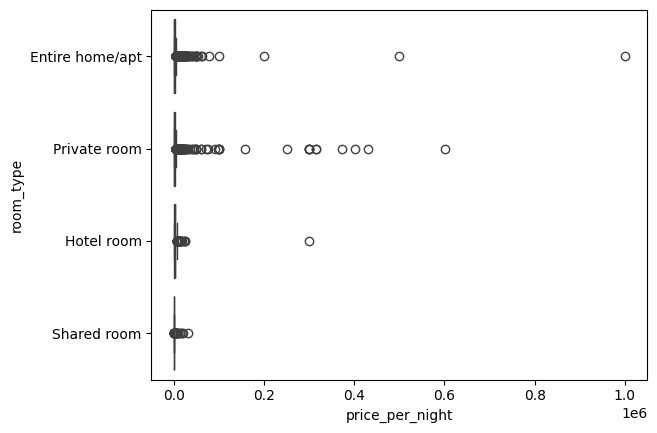

In [22]:
# Detect Outliers

sns.boxplot(data=df, x='price_per_night', y='room_type')

**OUTLIERS ANALYSIS**

Based on the normality test using the shapiro-wilk, it shows the data does not normally distributed, which when I perform boxplot, it shows that there are some outliers in the property prices for entire home/apartments, private rooms, and hotel rooms. These unusually high prices occur because accommodation owners can set their own rates according to their preferences. Therefore, it is not necessary to remove these outliers from the dataset as it is their personal decisions. The maximum outliers is 1.0 x 1e6 = 1,000,000 THB

In [23]:
# Identify hosts with high availability (> 200 days) and low bookings ( < 5 reviews)
high_avail_low_reviews = df[
    (df['availability_365'] > 200) & 
    (df['number_of_reviews'] < 5)
][['host_id', 'availability_365', 'number_of_reviews', 'price']]

# Sort by most idle days (availability)
high_avail_low_reviews = high_avail_low_reviews.sort_values(by='availability_365', ascending=False)
count_hosts = high_avail_low_reviews['host_id'].nunique()

# Display result
display(high_avail_low_reviews.head(10))
display(f"Total Hosts: {count_hosts}")

,host_id,availability_365,number_of_reviews,price
26,5297436,365,0,3082
15853,491526222,365,0,1214
15852,491526222,365,0,1214
2,123784,365,0,800
15851,491526222,365,0,1214
4,610315,365,0,1905
6,222005,365,1,1558
15845,491526222,365,0,1443
15846,491526222,365,0,1443
15847,340188343,365,0,2700


'Total Hosts: 3158'

**Explaination:**

Assumptions: No review, no bookings.
The data shows the high availability date with low bookings or even no bookings.
**Speculation > misaligned prices**

In [24]:
low_avail = df[(df['availability_365'] > 200)]
count_hosts_low = low_avail['host_id'].nunique()
display(low_avail)
display(f"Total Hosts: {count_hosts_low}")

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,last_review (Year),price_per_night
0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.759830,100.541340,Entire home/apt,1905,3,65,2020-01-06,0.50,2,353,0,2020,635
1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.668180,100.616740,Private room,1316,1,0,NaT,0.00,2,358,0,<NA>,1316
2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.752320,100.624020,Private room,800,60,0,NaT,0.00,1,365,0,<NA>,13
3,35780,Spacious one bedroom at The Kris Condo Bldg. 3,153730,Sirilak,Din Daeng,13.788230,100.572560,Private room,1286,7,2,2022-04-01,0.03,1,323,1,2022,183
4,941865,Suite Room 3 at MetroPoint,610315,Kasem,Bang Kapi,13.768720,100.633380,Private room,1905,1,0,NaT,0.00,3,365,0,<NA>,1905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15849,790465040741092826,素坤逸核心两房公寓42楼，靠近BTSon nut/无边天际泳池观赏曼谷夜景/出门当地美食街,94899359,Renee,Pra Wet,13.715132,100.653458,Private room,2298,28,0,NaT,0.00,1,362,0,<NA>,82
15850,790474503157243541,Euro LuxuryHotel PratunamMKt TripleBdNrShoping...,491526222,Phakhamon,Ratchathewi,13.753052,100.538738,Private room,1429,1,0,NaT,0.00,14,365,0,<NA>,1429
15851,790475335086864240,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.753169,100.538700,Private room,1214,1,0,NaT,0.00,14,365,0,<NA>,1214
15852,790475546213717328,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.754789,100.538757,Private room,1214,1,0,NaT,0.00,14,365,0,<NA>,1214


'Total Hosts: 4164'

## A. Airbnb Pricing Performance

Success on Airbnb depends heavily on setting the right price. One that is attractive to guests while still maximizing revenue. However, determining the optimal price is challenging because it is influenced by multiple factors such as room type, location, minimum stay requirements, and listing availability. Using the provided dataset, this analysis aims to evaluate whether current prices are reasonable and identify the key factors that influence listing popularity.

**Analysis Scope:**
1. Price Fairness and Value Assessment
2. Price per Night Sensitivity to Location (Accroding to Room Type)

In [25]:
# However, Let's see the overall price 

max_price = df['price'].max()
# Finding the lowest price where price is not equal to 0
min_price = df[df['price'] > 0]['price'].min()
print(f'Maximum price = {max_price}')
print(f'Minimum price = {min_price}')

Maximum price = 1100000
Minimum price = 278


In [26]:
# Detecting Price Outliers

q3 = df['price'].describe()['75%']
print(f'Q3 (75th percentile) = {q3}')

q1 = df['price'].describe()['25%']
print(f'Q1 (25th percentile) = {q1}')

upperbound = q3 + (iqr(df['price']) * 1.5)
print(f'Upper Bound = {upperbound}')

lowerbound = q1 - (iqr(df['price']) * 1.5)
print(f'Lower Bound = {lowerbound}')

Q3 (75th percentile) = 2429.0
Q1 (25th percentile) = 900.0
Upper Bound = 4722.5
Lower Bound = -1393.5


In [27]:
# lowerbound is not needed as logically price must be not 0, and lowerbound is negative (-1393.5).
outliers = len(df[df['price'] > upperbound])
total = len(df)
display(outliers/total)

0.0885005992556614

**FINDINGS**

The dataset shows a very wide range of prices, from a minimum of 278 to a maximum of 1,100,000.
There are a considerable number of outliers (about 8.8% of the data). Within these, we will provide two different plot for prices range 0 - 4800 (rounded from 4722.5) THB and the upper bound. 

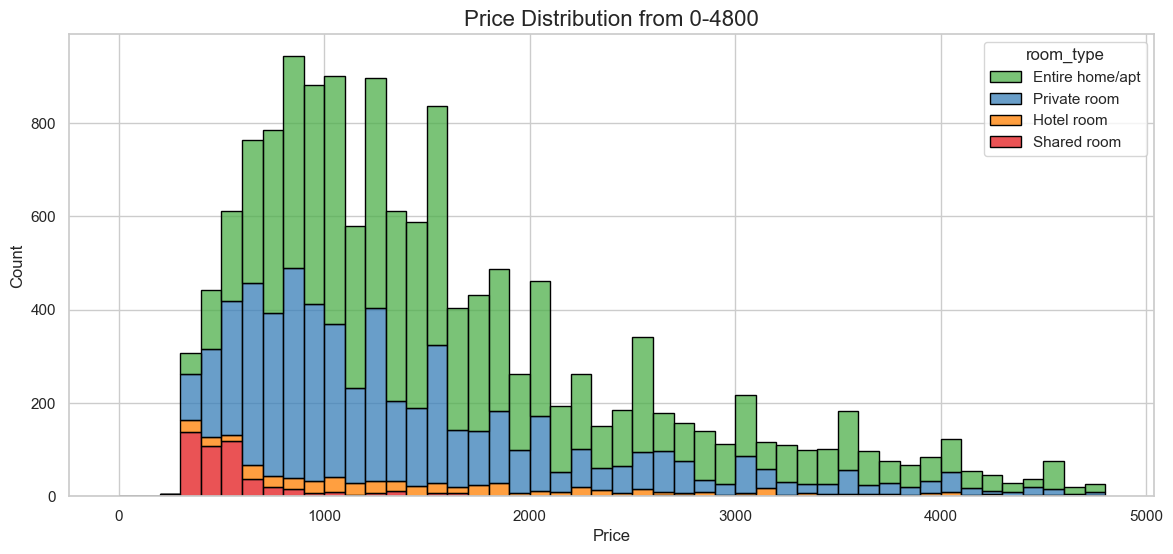

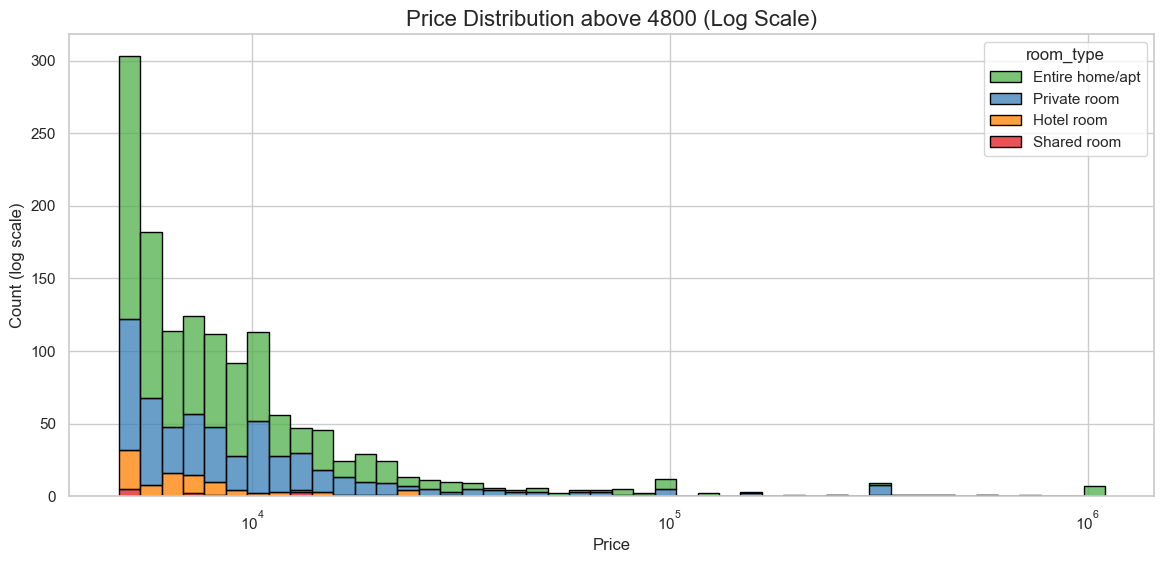

In [28]:
# Define bin edges
bins_low = np.arange(0, 4801, 100)
sns.set_theme(style='whitegrid')

# Room Type distribution by color palette
palette = {
    'Entire home/apt': '#4daf4a',  
    'Private room': '#377eb8',     
    'Hotel room': '#ff7f00',   
    'Shared room': '#e41a1c'   
}

# Price distribution from 0-4800
plt.figure(figsize=(14,6))
sns.histplot(
    data=df[df['price'] < 4800], 
    x = 'price', 
    bins = bins_low, 
    hue = 'room_type', 
    hue_order = ['Entire home/apt','Private room','Hotel room','Shared room'],
    multiple ='stack',
    palette = palette,
    edgecolor = 'black'
)
plt.title('Price Distribution from 0-4800', fontsize=16)
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

# Price distribution above 4800
plt.figure(figsize=(14,6))
sns.histplot(
    data=df[df['price'] >= 4800], 
    x ='price', 
    hue = 'room_type',
    hue_order =['Entire home/apt','Private room','Hotel room','Shared room'],
    multiple ='stack',
    palette = palette,

    edgecolor = 'black',
    log_scale = True
)
plt.title('Price Distribution above 4800 (Log Scale)', fontsize=16)
plt.xlabel('Price')
plt.ylabel('Count (log scale)')
plt.show()

From the graph, we can observe that the frequency of listings drops sharply for prices above 1.1 × 10⁴.
Prices above this threshold can be considered luxury listings, which cater to a specific segment of guests who prioritize exclusivity and premium experiences which are dominated by entire home/apt and private room. 

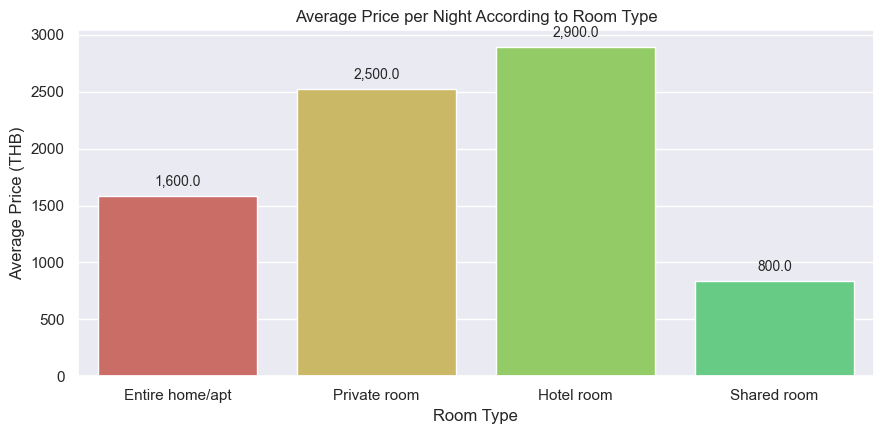

In [29]:
# Visualization for Average Price per Night for Room Type

plt.figure(figsize=(9,4.5))
sns.set_theme()

ax = sns.barplot(
    data=df,
    x ='room_type',
    y ='price_per_night',
    estimator = np.mean,
    errorbar = None,
    palette = sns.color_palette("hls", 8)
)

for bar in ax.patches:
    value = round(bar.get_height(), -2)
    ax.annotate(f'{value:,}',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0,5),
                textcoords='offset points')

ax.set(
    xlabel='Room Type',
    ylabel='Average Price (THB)',
    title='Average Price per Night According to Room Type'
)

plt.tight_layout()
plt.show()


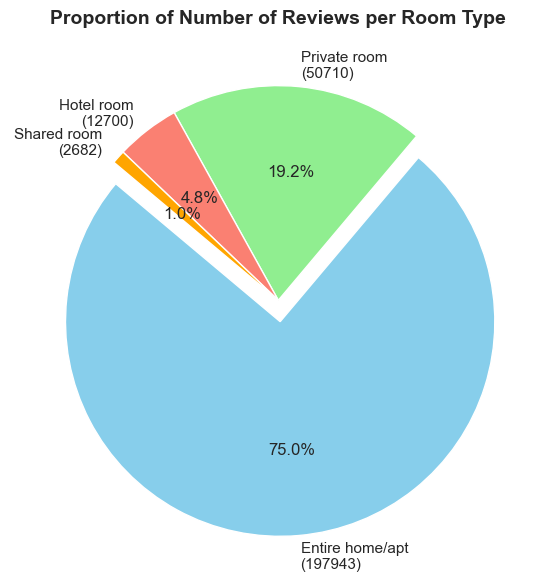

In [30]:
# Visualization of the Proportion of Number of Reviews per Room Type

# Aggregate total reviews per room type
data_room_type = df.groupby('room_type')['number_of_reviews'].sum().reset_index()

# Sort descending
data_room_type = data_room_type.sort_values(by='number_of_reviews', ascending=False)

sizes = data_room_type['number_of_reviews'].values
labels = [f"{room}\n({num})" for room, num in zip(data_room_type['room_type'], data_room_type['number_of_reviews'])]

# Explode largest slice for emphasis
explode = [0.1 if i == max(sizes) else 0 for i in sizes]

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    explode=explode,
    shadow=False,
    startangle=140,
    colors=['skyblue','lightgreen','salmon','orange']
)
plt.title('Proportion of Number of Reviews per Room Type', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


## **Price Fairness & Value Assessment**


**1. Entire Home / Apartment - Avg 1,600 THB/night (75% listings)**

✅ Good value / slightly underpriced
- Full privacy, kitchen, more space.
Lower than hotel room pricing = very competitive.
Likely optimized for long-term stays & group bookings.
- Potential: Can safely increase price during peak dates or for high-amenity units. (with good views, balcony, or etc.)

**2. Private Room - Avg 2,500 THB/night (19.2% listings)**

⚠️ Slightly premium compared to Entire Apt
- Guests share common areas but pay more per night than full apartment.
- However, This is only justified if:
a. inside luxury condo,
b. excellent BTS proximity,
c. premium interior or host service.

✅ Still fair if marketed as “hotel alternative + home feel”

**3. Hotel Room - Avg 2,900 THB/night (4.8% listings)**

✅ Fair - service premium pricing
- Justified by 24h reception, daily cleaning, security, amenities.
- Travelers are paying for convenience and predictability, not space.
- Competes directly with other website such as Agoda/Booking.com users.

**4. Shared Room - Avg 800 THB/night (1% listings)**

✅ Very fair / budget-friendly
- Targets backpackers, students, interns.
- Under 1,000 THB/night → well-positioned as cheapest safe option.
- Works well if near universities and metro lines.

## **Recommendations**

1. **Entire Home / Apartment (avg 1,600 THB/night - slightly underpriced)**

- Recommendation: 

    1. Consider raising rates slightly during peak periods or weekends which it might be cheaper compare to the hotel room.
    2. Offer long-stay discounts instead of lowering the nightly price.
    3. Highlight premium amenities to charge higher rates for certain units. (China's accomodation also provide requested ammenities)

2. **Private Room (avg 2,500 THB/night - slightly premium)**

Concern: Guests share common spaces but pay more than a full apartment

- Recommendation:

    1. If the unit is premium, keep the rate and market it as a “hotel alternative with home comfort.”
    2. If not, consider slightly lowering the price to stay competitive with nearby entire apartments.

3. **Hotel Room (avg 2,900 THB/night - fair)**

- Recommendation: 

    1. Keep the price steady, and focus on listing across multiple platforms like Agoda and Booking.com to capture short-term travelers to maintain exposure.
    2. Using dynamic pricing can help take advantage of holidays, peak season, or local events.

4. **Shared Room (avg 800 THB/night - very fair)**

- Recommendation: 

    1.  Maintain the price to remain attractive to budget travelers.
    2. Emphasize social aspects, like community events or co-living spaces (added value) as is not only marketed as the cheapest option. 

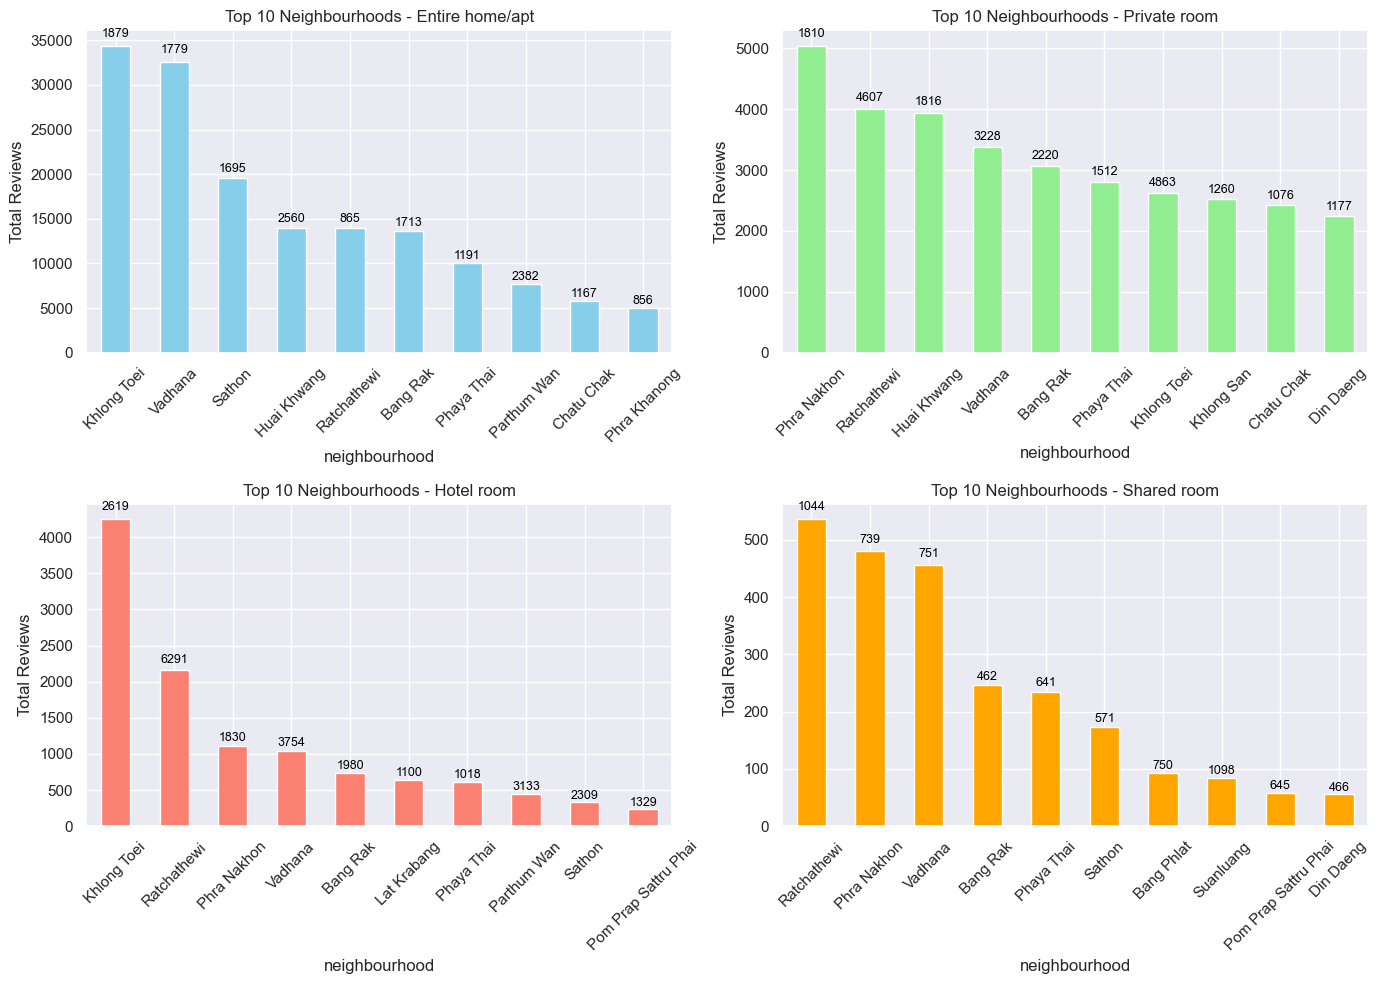

In [31]:
room_types = df['room_type'].unique()
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

# Specific colors for each room type
room_colors = {
    'Entire home/apt': 'skyblue',
    'Private room': 'lightgreen',
    'Hotel room': 'salmon',
    'Shared room': 'orange'
}

for i, room in enumerate(room_types):
    df_room = df[df['room_type'] == room]
    
    # Aggregate total reviews by neighbourhood and its average price
    top_neigh = df_room.groupby('neighbourhood')['number_of_reviews'].sum().sort_values(ascending=False).head(10)
    avg_price = df_room.groupby('neighbourhood')['price_per_night'].mean().reindex(top_neigh.index)
    
    # Plot
    color = room_colors.get(room, 'gray')
    ax = axes[i]
    top_neigh.plot(kind='bar', ax=ax, color=color)
    
    # Add price labels on top of bars
    for j, val in enumerate(top_neigh):
        price_label = f"{avg_price.iloc[j]:.0f}" 
        ax.text(j, val + val*0.02, price_label, ha='center', va='bottom', fontsize=9, color='black')
    
    ax.set_title(f'Top 10 Neighbourhoods - {room}')
    ax.set_ylabel('Total Reviews')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Price per Night Sensitivity to Location (Accroding to Room Type)

1. **Entire apartments are most common in Khlong Toei, Vadhana, and Sathorn.** These are Bangkok’s premium expat zones, surrounded by BTS stations, international offices like embassy zone, shopping malls like Emquartier, and Japanese/Korean corporate clusters. These areas naturally attract long-stay professionals and remote workers, not short-term tourists. At ~1,600 THB/night, they’re actually slightly underpriced considering the area’s profile. Hotels in the same districts easily go for double. Dynamic pricing is possible.
Link: https://thaivisaexpert.com/best-places-to-live-in-bangkok-for-expats-in-2025/

2. **Private rooms are concentrated in Phra Nakhon, Ratchathewi, and Huai Khwang.** These are areas known for universities (Chulalongkorn, Thammasat University), Khao San backpacker tourism, and strong Chinese travel demand as it is surrounded with chinese expats. So the crowd here is mostly young travelers, students, backpackers — people who want comfort, but don’t need a full apartment. ~2,500 THB/night is reasonable or even slightly premium, but justified if the property is modern or condo-style.
Link: https://www.bangkokpost.com/thailand/general/2632507/rough-start-for-new-chinatown

3. **Hotel rooms show up most in Khlong Toei, Ratchathewi, and Phra Nakhon**, which perfectly reflects tourism behavior. central, connected, and accessible. Hotel also provide comfortability in their services. ~2,900 THB/night is exactly what travelers would expect for a hotel experience in central Bangkok.

4. **Shared rooms are most common in Ratchathewi, Phra Nakhon, and Vadhana**. This is interesting as Vadhana is known as an upscale area, but it also has a strong nightlife/hostel scene (Thonglor–Ekkamai), drawing young social also solo travelers. In addition, as Ratchathewi near university, it becomes a good place to stay for students doing exchange for several days. ~800 THB/night is very fair.

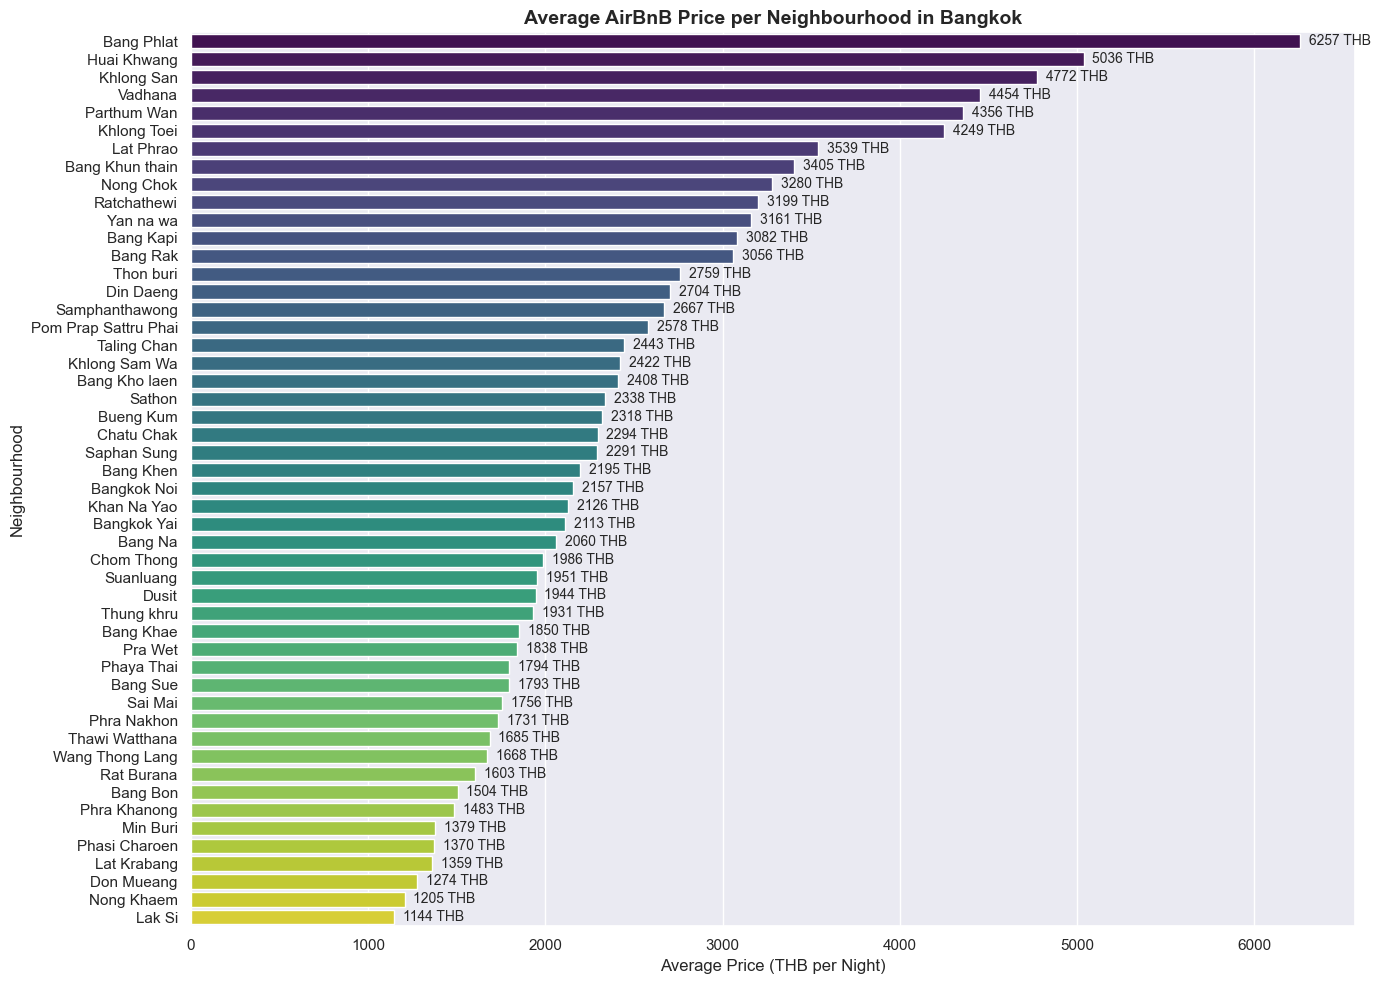

In [32]:
df_neighbourhood = (
    df.groupby('neighbourhood')['price']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(14,10))
sns.barplot(
    data=df_neighbourhood,
    y='neighbourhood',
    x='price',
    order=df_neighbourhood['neighbourhood'],
    ci=None,
     palette='viridis'
)

plt.title('Average AirBnB Price per Neighbourhood in Bangkok', fontsize=14, weight='bold')
plt.xlabel('Average Price (THB per Night)', fontsize=12)
plt.ylabel('Neighbourhood', fontsize=12)

# add labels to bar
for index, row in df_neighbourhood.iterrows():
    plt.text(row['price'] + 50, index, f"{row['price']:.0f} THB", va='center', fontsize=10)

plt.tight_layout()
plt.show()


## Airbnb Price Disparity Analysis (Bangkok Neighbourhoods)

**- Top 5 High-Price Neighbourhoods -**

**Bang Phlat, Huai Khwang, Khlong San, Vadhana, Parthum Wan**

### Common Characteristics
1. **Central or Semi-Central Locations**  
   - *Parthum Wan*: Bangkok’s core — Siam, MBK, Chulalongkorn University.  
   - *Vadhana*: Thonglor–Ekkamai–Asoke area, famous for expat life and nightlife.  
   - *Khlong San*: Riverside zone near ICONSIAM, high-end riverside apartments.  
   - *Huai Khwang*: MRT-connected (Rama 9, Ratchada), popular among digital nomads and Chinese visitors.  
   - *Bang Phlat*: Near river, newer condos, growing development projects.  


---


**- Top 5 Low-Price Neighbourhoods -**

**Lak Si, Nong Khaem, Don Mueang, Lat Krabang, Phasi Charoen**

### Common Characteristics
1. **Peripheral / Outer Bangkok Areas**  
   - Far from main commercial centers *(Sukhumvit, Silom, Siam)*.
   - Longer commuting time → less attractive for short-term stays.
   - Limited MRT/BTS lines so it becomes less convenient routes.
   - Lat Krabang and Don Mueang mostly serve airport or factory workers to live.
   - Limited tourists places.

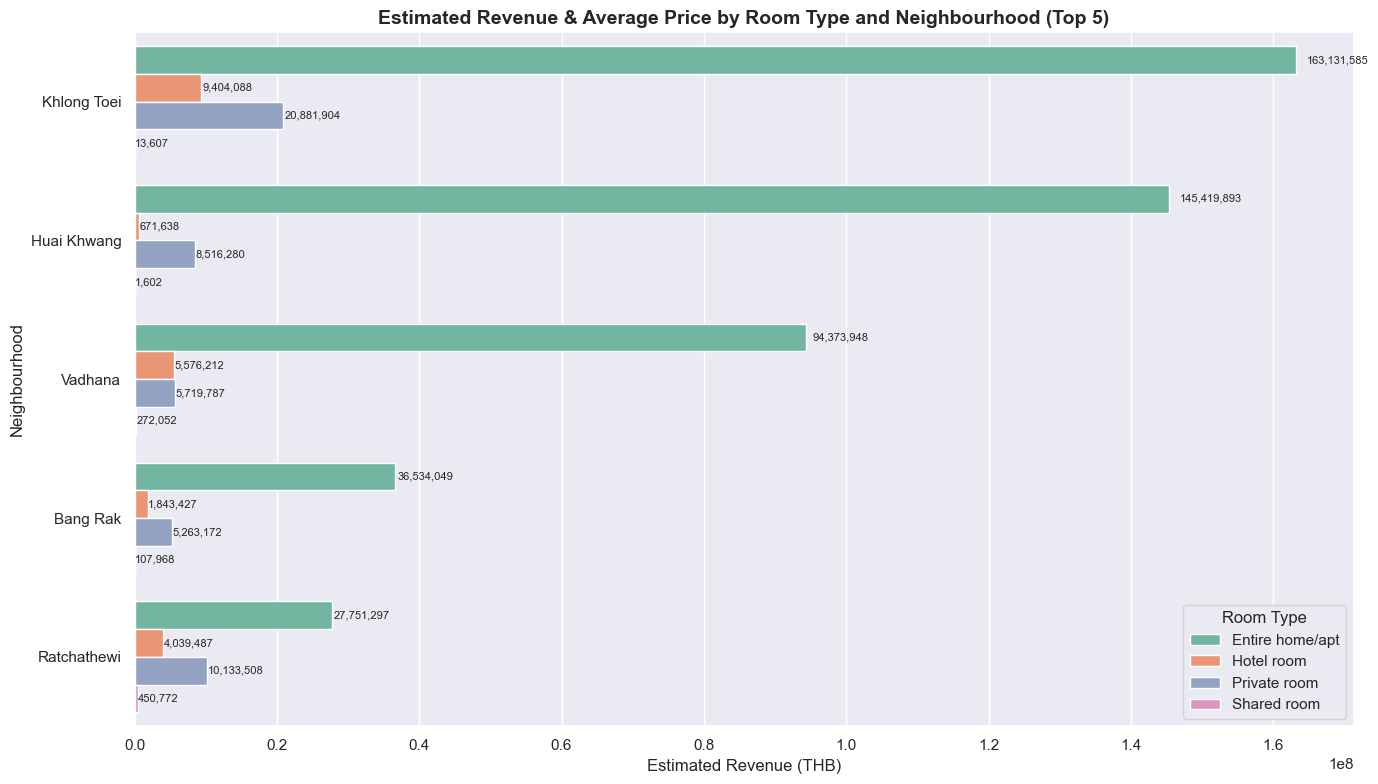

In [33]:
# Estimate revenue using number_of_reviews 
df['estimated_revenue'] = df['price'] * df['number_of_reviews']

# Aggregate revenue and average price by room_type and neighbourhood
revenue_summary = (
    df.groupby(['neighbourhood', 'room_type'])
      .agg(estimated_revenue=('estimated_revenue', 'sum'),
           avg_price=('price', 'mean'))
      .reset_index()
)

# Pick top 5 neighborhoods by total revenue
top_neigh = revenue_summary.groupby('neighbourhood')['estimated_revenue'].sum() \
                           .sort_values(ascending=False).head(5).index
revenue_top = revenue_summary[revenue_summary['neighbourhood'].isin(top_neigh)]

# Sort revenue_top by total revenue descending for plotting
revenue_top['total_by_neigh'] = revenue_top.groupby('neighbourhood')['estimated_revenue'].transform('sum')
revenue_top = revenue_top.sort_values(by='total_by_neigh', ascending=False)

# Plot
plt.figure(figsize=(14,8))
ax = sns.barplot(
    data=revenue_top,
    x='estimated_revenue',
    y='neighbourhood',
    hue='room_type',
    ci=None,
    palette='Set2',
    dodge=True  
)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 0.01*width,
            p.get_y() + p.get_height()/2,
            f'{int(width):,}',
            va='center',
            ha='left',
            fontsize=8
        )

plt.title('Estimated Revenue & Average Price by Room Type and Neighbourhood (Top 5)', fontsize=14, weight='bold')
plt.xlabel('Estimated Revenue (THB)')
plt.ylabel('Neighbourhood')
plt.legend(title='Room Type')
plt.tight_layout()
plt.show()


**Revenue Drivers**

Top 3 :
- **Khlong Toei**: High revenue driven mostly by **Entire Home/Apt** and **Private Room**.
- **Huai Khwang**: Revenue dominated by **Entire Home/Apt** and **Private Room**.
- **Vadhana**: Revenue comes primarily from **Entire Home/Apt** However, **Private Rooms** and **Hotel Room** remains competitive.

## B. Duplicated Data and No Name Deep Analysis

In [34]:
# FINDINGS DUPLICATED DATA

data_duplicate = df[df.duplicated(subset=['longitude', 'latitude','last_review','price','name','room_type'])]
display(data_duplicate)
print(f'The number of identical properties is {len(data_duplicate)} property')

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,last_review (Year),price_per_night,estimated_revenue
5976,28907857,NA BANGLAMPOO GUEST HOUSE,87704107,Yui,Phra Nakhon,13.762790,100.497900,Private room,1400,1,0,NaT,0.0,9,361,0,<NA>,1400,0
8790,37954129,small1,97598307,Soo,Don Mueang,13.920720,100.575780,Shared room,350,1,0,NaT,0.0,4,180,0,<NA>,350,0
15121,767128654727724698,Sathon Luxury Loft/China Town/Icon Siam,276781306,Alex,Sathon,13.710777,100.519891,Entire home/apt,1580,1,0,NaT,0.0,13,339,0,<NA>,1580,0
15144,767945912006659422,Sathon Luxury Loft/China Town/Icon Siam,344327171,Alice,Sathon,13.710777,100.519891,Entire home/apt,1580,1,0,NaT,0.0,40,339,0,<NA>,1580,0
15186,765691389894680033,Sathon Luxury 2 br/China Town/Icon Siam,264864968,Tricia,Sathon,13.710777,100.519891,Entire home/apt,2221,1,0,NaT,0.0,44,340,0,<NA>,2221,0
15190,765716244664642439,Sathon Luxury 2 br/China Town/Icon Siam,344327171,Alice,Sathon,13.710777,100.519891,Entire home/apt,2221,1,0,NaT,0.0,40,340,0,<NA>,2221,0
15191,765721954905526928,Sathon Luxury 2 br/China Town/Icon Siam,344327171,Alice,Sathon,13.710777,100.519891,Entire home/apt,2221,1,0,NaT,0.0,40,340,0,<NA>,2221,0
15192,765728211212001811,Sathon Luxury 2 br/China Town/Icon Siam,276781306,Alex,Sathon,13.710777,100.519891,Entire home/apt,2221,1,0,NaT,0.0,13,340,0,<NA>,2221,0
15195,765781484209218358,Sathon Luxury 2 br/China Town/Icon Siam,20133201,Willam,Sathon,13.710777,100.519891,Entire home/apt,2221,1,0,NaT,0.0,33,340,0,<NA>,2221,0
15371,775777794097427183,New! Gateway/ Bangkok University 1BR 2PPL near...,52161947,Noons,Khlong Toei,13.716669,100.584967,Entire home/apt,2976,1,0,NaT,0.0,99,362,0,<NA>,2976,0


The number of identical properties is 14 property


In [35]:
data_duplicate.groupby(['name','latitude','longitude','host_name'])[['id']].count()

id
name                                               latitude  longitude  host_name    
Family Room for 4 People                           13.740168 100.556320 Rachan      1
Luxury 1 Bed/Central Rama9/Jodds Fair/Phra ram9    13.756184 100.568269 Tricia      1
                                                                        Willam      1
                                                   13.757097 100.568486 Alice       1
NA BANGLAMPOO GUEST HOUSE                          13.762790 100.497900 Yui         1
New! Gateway/ Bangkok University 1BR 2PPL near BTS 13.716669 100.584967 Noons       1
Sathon Luxury 2 br/China Town/Icon Siam            13.710777 100.519891 Alex        1
                                                                        Alice       2
                                                                        Tricia      1
                                                                        Willam      1
Sathon Luxury Loft/China Town/Icon Siam            13.710777 100.519891 Alex        1
                                                                        Alice       1
small1                                             13.920720 100.575780 Soo         1

**DUPLICATE ANALYSIS:**

The duplicate data shows that some properties with the same name and identical latitude and longitude appear as separate listings under slightly different names. In reality, these are the same property, as indicated by the same price, last review date, and property type. This creates a serious booking problem: if one person books the property, another person may still see it as available and attempt to book it, thinking it is free to book which caused a major problem according to the review. So, we have to drop it to the first person who register. 

In [36]:
df.drop_duplicates(subset=['longitude', 'latitude','last_review','price','name','room_type'], keep='first', inplace=True, ignore_index=False)

In [37]:
no_name_airbnb = df[df['name'].isnull()]
no_name_airbnb

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,last_review (Year),price_per_night,estimated_revenue
439,4549768,NaN,18852579,Titawan,Phra Khanong,13.69406,100.59619,Private room,1080,5,0,NaT,0.00,1,365,0,<NA>,216,0
544,4720818,NaN,24386225,Cherry,Din Daeng,13.77562,100.57346,Private room,1200,1,0,NaT,0.00,1,365,0,<NA>,1200,0
572,4245018,NaN,22030043,Parichart,Bang Phlat,13.78376,100.49821,Private room,1200,1,0,NaT,0.00,1,365,0,<NA>,1200,0
669,6148415,NaN,31895202,Chira,Bang Na,13.68276,100.60894,Entire home/apt,2424,2,0,NaT,0.00,1,365,0,<NA>,1212,0
1030,8055144,NaN,42521288,Nantida,Vadhana,13.74126,100.55761,Private room,5000,3,0,NaT,0.00,1,365,0,<NA>,1666,0
1282,10000742,NaN,51374914,Diamond Bangkok,Ratchathewi,13.75328,100.52928,Private room,930,1,6,2017-05-13,0.07,1,365,0,2017,930,5580
1594,10710165,NaN,55347997,Khaneungnit,Vadhana,13.71757,100.60464,Private room,1000,1,0,NaT,0.00,1,365,0,<NA>,1000,0


In [38]:
df_no_name = no_name_airbnb.groupby('room_type').size()
df_no_name

room_type
Entire home/apt    1
Private room       6
dtype: int64

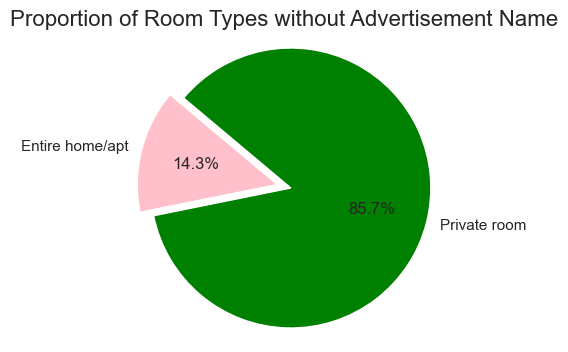

In [39]:
# Visualization of Air BnB with No Name Advertisement
explode = [0.1 if i == df_no_name.idxmax() else 0 for i in df_no_name.index]

# Create pie chart
plt.figure(figsize=(6, 4))
plt.pie(
    df_no_name, 
    labels=df_no_name.index, 
    autopct='%1.1f%%', 
    explode=explode, 
    startangle=140, 
    colors=['pink','green','blue','yellow']
)
plt.title('Proportion of Room Types without Advertisement Name', fontsize=16)
plt.axis('equal') 
plt.show()

# Insight – Listings Without Host Names

- Out of the listings with no host name:
  - **Private rooms:** 6 listings (~85,7%)  
  - **Entire home/apt:** 1 listing (~14,3%)  
- Most hosts include their name, which helps guests trust the listing. Listings without a name may feel less reliable, especially for private rooms where guests share space.

### Recommendations

1. **Add Host Name**  
   - Hosts should provide their name and profile picture to build trust.  

2. **Focus on Private Rooms**  
   - Since most nameless listings are private rooms, adding details like room rules, photos, and a short intro can improve bookings.  

3. **Platform Reminder**  
   - From Airbnb should have give reminder about the profile completion. 


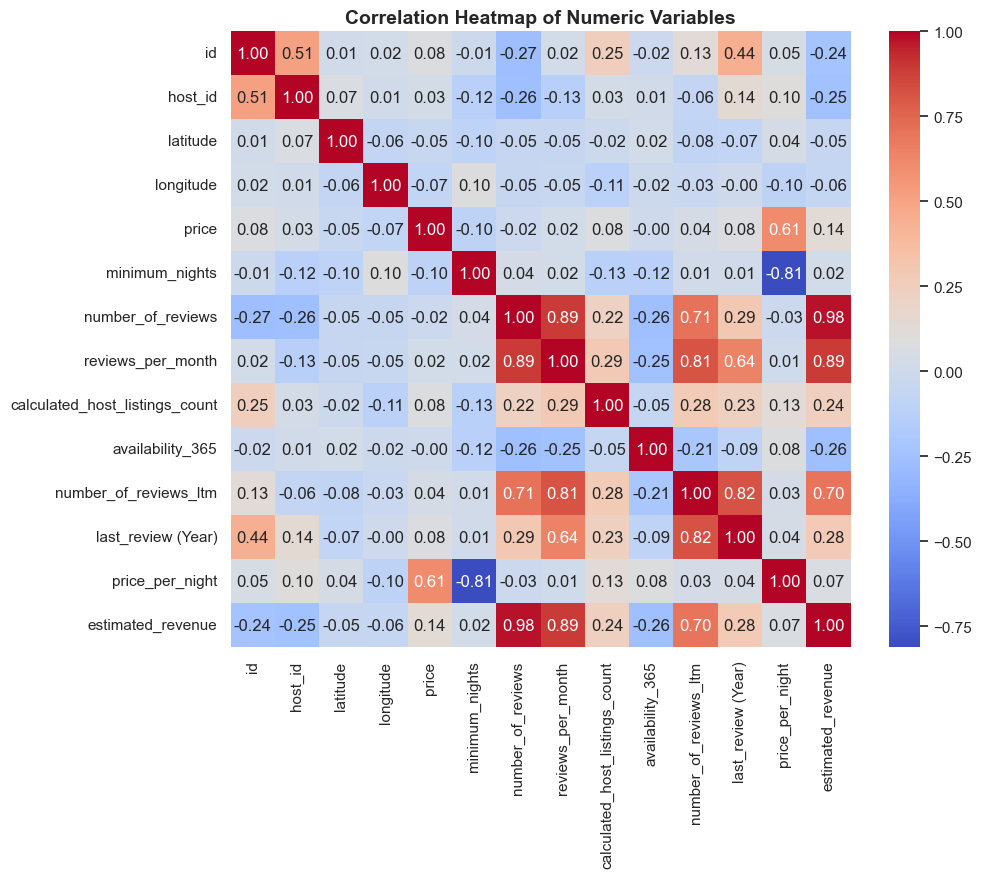

In [40]:
# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_cols.corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Numeric Variables", fontsize=14, weight='bold')
plt.show()

# Airbnb Correlation Heatmap Analysis - Bangkok

## Insights from Correlation Heatmap 

| Feature 1       | Feature 2          | Correlation | Insight                                                                 |
|-----------------|------------------|------------|-------------------------------------------------------------------------|
| Price           | Number of Reviews | -0.02      | Cheaper listings tend to get more reviews; budget options are booked more often. |
| Price           | Reviews per Month | 0.02       | Almost no correlation; high-priced listings don’t necessarily have more monthly bookings. |
| **Total Reviews**  | **Reviews per Month** | **0.78**       | **Strong positive correlation; listings with many total reviews are also actively booked** monthly. |
| Minimum Nights  | Price             | -0.10       | No correlation; Expensive listings don’t require longer minimum stays. |
| Availability 365| Price             | -0.00       | No correlation; being available all year does not guarantee higher price or bookings. |



In [41]:
# Reviews Assesment

data_review_month = df[df['last_review (Year)'].isin(years)]
data_review_month = data_review_month.groupby(['last_review (Year)', 'room_type'])[['number_of_reviews']].sum()
display(data_review_month)

number_of_reviews
last_review (Year) room_type                         
2012               Entire home/apt                  4
2013               Entire home/apt                 28
                   Private room                     2
2014               Entire home/apt                  4
                   Private room                    12
2015               Entire home/apt                 91
                   Private room                    88
                   Shared room                      3
2016               Entire home/apt                624
                   Hotel room                       3
                   Private room                   205
                   Shared room                     20
2017               Entire home/apt                843
                   Hotel room                      38
                   Private room                   442
                   Shared room                     84
2018               Entire home/apt               2446
                   Hotel room                     128
                   Private room                  1280
                   Shared room                    124
2019               Entire home/apt               5333
                   Hotel room                     897
                   Private room                  3840
                   Shared room                    546
2020               Entire home/apt              19682
                   Hotel room                    2259
                   Private room                  8870
                   Shared room                    612
2021               Entire home/apt               3770
                   Hotel room                     168
                   Private room                   256
                   Shared room                      5
2022               Entire home/apt             165118
                   Hotel room                    9207
                   Private room                 35715
                   Shared room                   1288

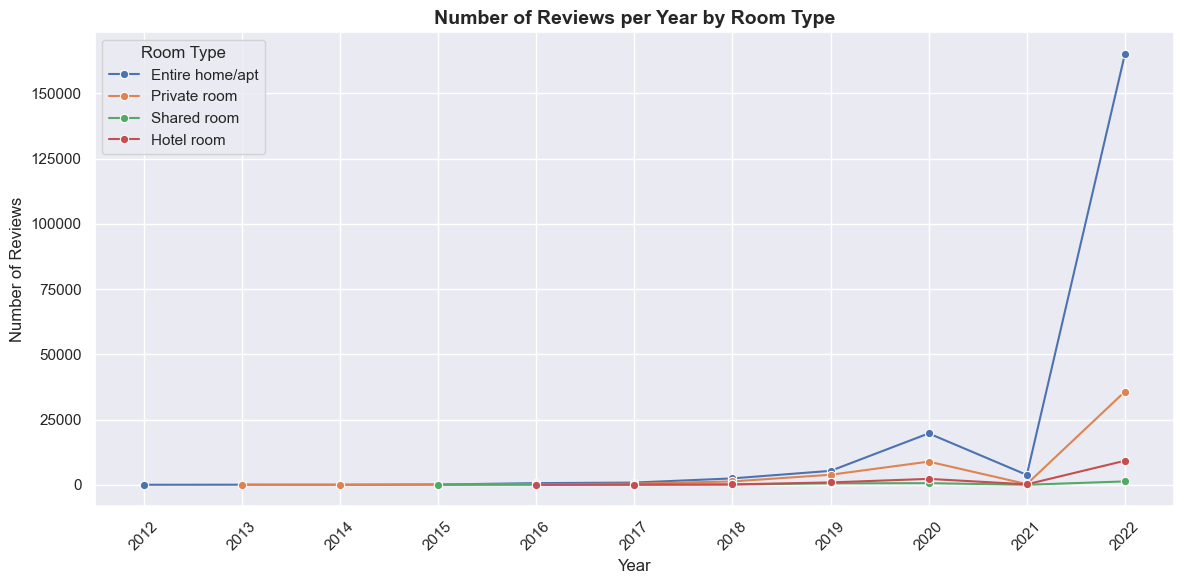

In [42]:
# Filter relevant years
years = list(range(2012, 2023))
data_review_year = df[df['last_review (Year)'].isin(years)]

# Aggregate number of reviews per year per room type
reviews_per_year = data_review_year.groupby(['last_review (Year)', 'room_type'])['number_of_reviews'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(
    data=reviews_per_year, 
    x='last_review (Year)', 
    y='number_of_reviews', 
    hue='room_type', 
    marker='o'
)

plt.title('Number of Reviews per Year by Room Type', fontsize=14, weight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.xticks(years, rotation=45)
plt.legend(title='Room Type')
plt.tight_layout()
plt.show()

# Bangkok Airbnb Review Trends (2012–2022)

## Overview
- From **2012–2019**, every room type had steady growth in reviews.  
- **2019–2020:** Apartment reviews increased noticeably, driven by domestic travelers and long-term stays.
- **2020–2021:** Reviews dropped due to **COVID-19 travel restrictions** and lockdowns.
- **2021–2022:** *Entire Apartments* reviews skyrocketed, surpassing Private Rooms and shared accommodations.

## Reasons for Entire Apartments Dominance
1. **Long-term stays & work-from-home:** Privacy and comfort became top priorities.
2. **Group & family bookings:** Apartments accommodate larger groups better and the able to get many reviews. 
3. **Safety concerns:** Travelers prefer self-contained spaces post-COVID.
4. **Policy & tourism recovery:** Short-term rental regulations relaxed in key districts; domestic tourism encouraged.
5. **Tourism rebound:** Central locations (**Vadhana, Huai Khwang, Khlong Toei**) highly booked by international travelers.

## Insights
- Entire Apartments are now **the most reviewed Airbnb type** in Bangkok.
- **Recommendation for hosts:** Focus on well-located, fully-equipped apartments to maximize occupancy, revenue, and reviews.


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15839 entries, 0 to 15853
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              15839 non-null  int64         
 1   name                            15832 non-null  object        
 2   host_id                         15839 non-null  int64         
 3   host_name                       15839 non-null  object        
 4   neighbourhood                   15839 non-null  object        
 5   latitude                        15839 non-null  float64       
 6   longitude                       15839 non-null  float64       
 7   room_type                       15839 non-null  object        
 8   price                           15839 non-null  int64         
 9   minimum_nights                  15839 non-null  int64         
 10  number_of_reviews               15839 non-null  int64         
 11  last_re

In [44]:
df.to_csv('Airbnb Listings Bangkok_clean.csv',index=False)